# NovaCorp EDA

**Problem statement:** NovaCorp is losing an estimated $42M/year to preventable attrition, disengagement, and hiring inefficiency.

**Goal of this notebook:** dig into all four datasets, find patterns, and find candidate root causes before we commit to one problem to analyse in depth.

Datasets: `employees.csv` (master), `attrition_log.csv` (leavers), `engagement.csv` (quarterly pulse), `performance.csv` (ratings/promotion).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
FIG_DIR = "../outputs/figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)

DATA_DIR = "../novacorp_datasets"
emp = pd.read_csv(f"{DATA_DIR}/employees.csv", parse_dates=["hire_date", "exit_date"])
att = pd.read_csv(f"{DATA_DIR}/attrition_log.csv", parse_dates=["exit_date"])
eng = pd.read_csv(f"{DATA_DIR}/engagement.csv", parse_dates=["survey_date"])
perf = pd.read_csv(f"{DATA_DIR}/performance.csv", parse_dates=["review_date"])

for name, df in [("employees", emp), ("attrition_log", att), ("engagement", eng), ("performance", perf)]:
    print(f"{name}: {df.shape}")


employees: (13403, 24)
attrition_log: (1400, 10)
engagement: (55971, 12)
performance: (34979, 7)


## Data quality check

In [2]:
for name, df in [("employees", emp), ("attrition_log", att), ("engagement", eng), ("performance", perf)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    print(f"--- {name} ---")
    print(nulls if len(nulls) else "no nulls")
    print()


--- employees ---
exit_date     12003
manager_id        1
dtype: int64

--- attrition_log ---
no nulls

--- engagement ---
manager_effectiveness        10264
psychological_safety         10264
recognition                  10264
career_development           10264
senior_leadership_trust      10264
purpose_meaning              10264
wellbeing                    10264
confidence_in_role_future    10264
dtype: int64

--- performance ---
no nulls



In [3]:
# employees.status vs attrition_log row count should reconcile
print("employees marked departed:", (emp["status"] == "departed").sum())
print("attrition_log rows:", len(att))
print("employee_ids in both:", emp[emp['status']=='departed']['employee_id'].isin(att['employee_id']).mean())


employees marked departed: 1400
attrition_log rows: 1400
employee_ids in both: 1.0


## Who works at NovaCorp

Show headcount, tenure and role distribution.

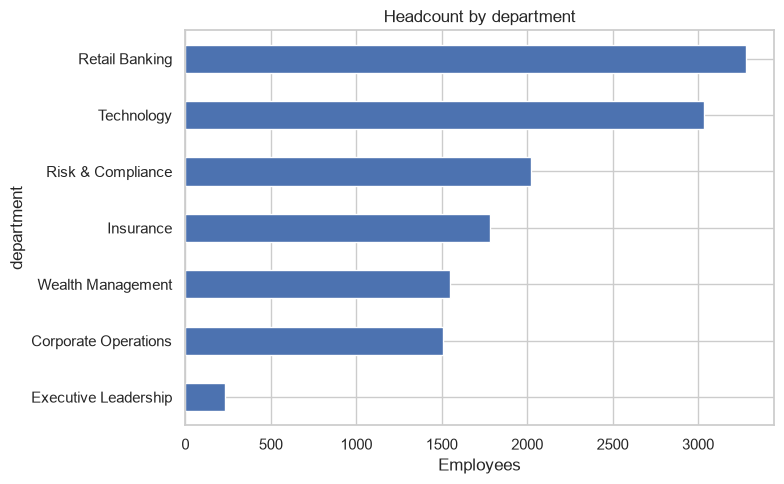

In [4]:
dept_counts = emp["department"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
dept_counts.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Headcount by department")
ax.set_xlabel("Employees")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/headcount_by_department.png", dpi=150)
plt.show()


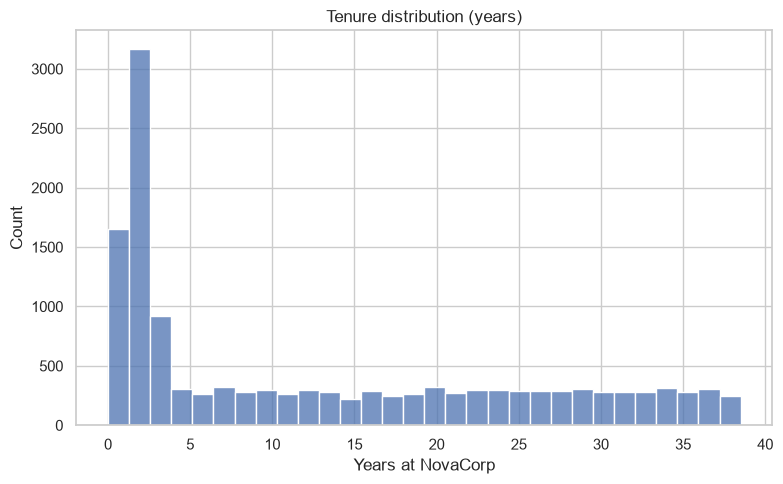

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(emp["tenure_months"] / 12, bins=30, ax=ax, color="#4C72B0")
ax.set_title("Tenure distribution (years)")
ax.set_xlabel("Years at NovaCorp")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/tenure_distribution.png", dpi=150)
plt.show()


## Attrition patterns

Where is attrition concentrated, and does it match what the FY2025 annual report already hints at (Entity_B integration risk, Risk & Compliance regulatory talent loss)?

Overall attrition rate: 10.4%
department
Risk & Compliance       11.8
Corporate Operations    11.6
Wealth Management       10.5
Technology              10.4
Insurance               10.3
Retail Banking           9.3
Executive Leadership     8.3
Name: status, dtype: float64


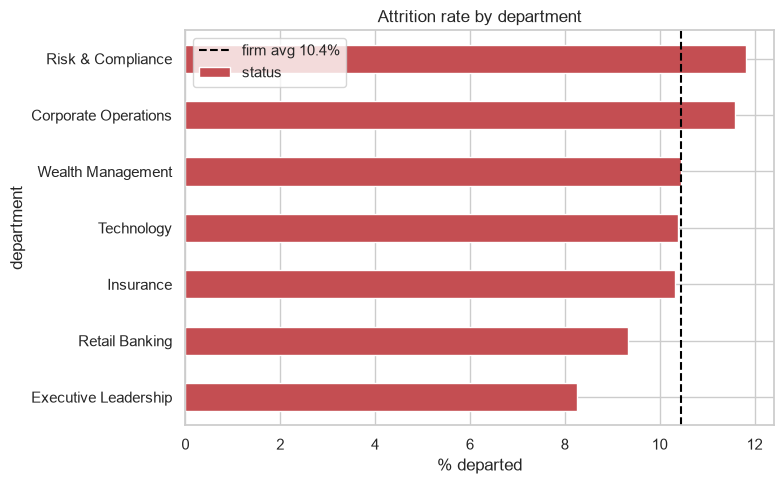

In [6]:
overall_rate = (emp["status"] == "departed").mean() * 100
print(f"Overall attrition rate: {overall_rate:.1f}%")

rate_by_dept = emp.groupby("department")["status"].apply(lambda s: (s == "departed").mean() * 100).sort_values(ascending=False)
print(rate_by_dept.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
rate_by_dept.sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.axvline(overall_rate, color="black", linestyle="--", label=f"firm avg {overall_rate:.1f}%")
ax.set_title("Attrition rate by department")
ax.set_xlabel("% departed")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/attrition_by_department.png", dpi=150)
plt.show()


legacy_entity_code
Entity_B           15.0
NovaCorp-Origin    10.3
Entity_C            9.3
Entity_A            7.5
Name: status, dtype: float64


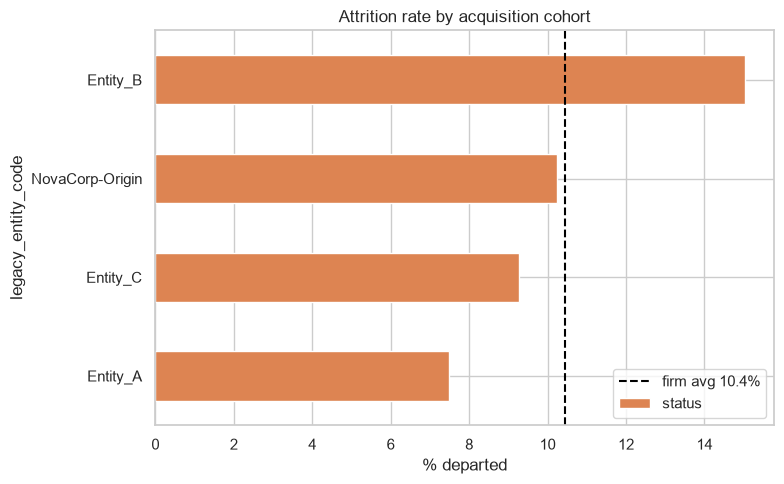

In [7]:
# Acquisition cohort hypothesis: does legacy_entity_code (pre-acquisition entity) predict attrition?
rate_by_cohort = emp.groupby("legacy_entity_code")["status"].apply(lambda s: (s == "departed").mean() * 100).sort_values(ascending=False)
print(rate_by_cohort.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
rate_by_cohort.sort_values().plot(kind="barh", ax=ax, color="#DD8452")
ax.axvline(overall_rate, color="black", linestyle="--", label=f"firm avg {overall_rate:.1f}%")
ax.set_title("Attrition rate by acquisition cohort")
ax.set_xlabel("% departed")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/attrition_by_cohort.png", dpi=150)
plt.show()


role_level
1    11.6
2    11.2
3    12.8
4    22.2
5     7.1
6     0.0
Name: status, dtype: float64


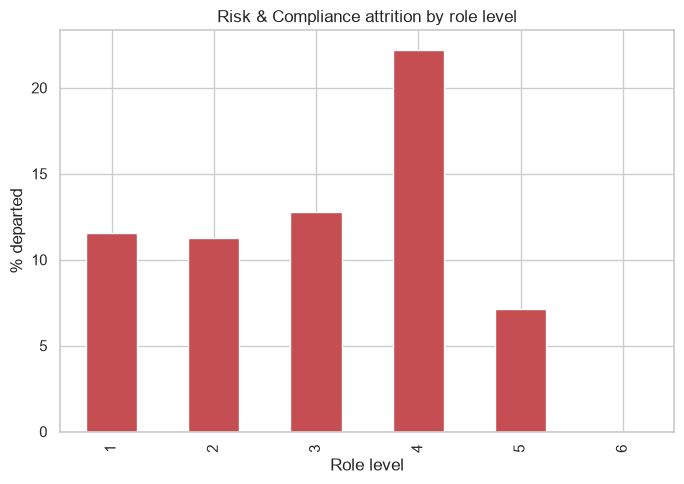

In [8]:
# Drill into Risk & Compliance by role_level - the annual report flags Director-level (L4) FAR pressure
rc_by_level = emp[emp["department"] == "Risk & Compliance"].groupby("role_level")["status"].apply(
    lambda s: (s == "departed").mean() * 100
)
print(rc_by_level.round(1))

fig, ax = plt.subplots(figsize=(7, 5))
rc_by_level.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_title("Risk & Compliance attrition by role level")
ax.set_xlabel("Role level")
ax.set_ylabel("% departed")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/rc_attrition_by_level.png", dpi=150)
plt.show()


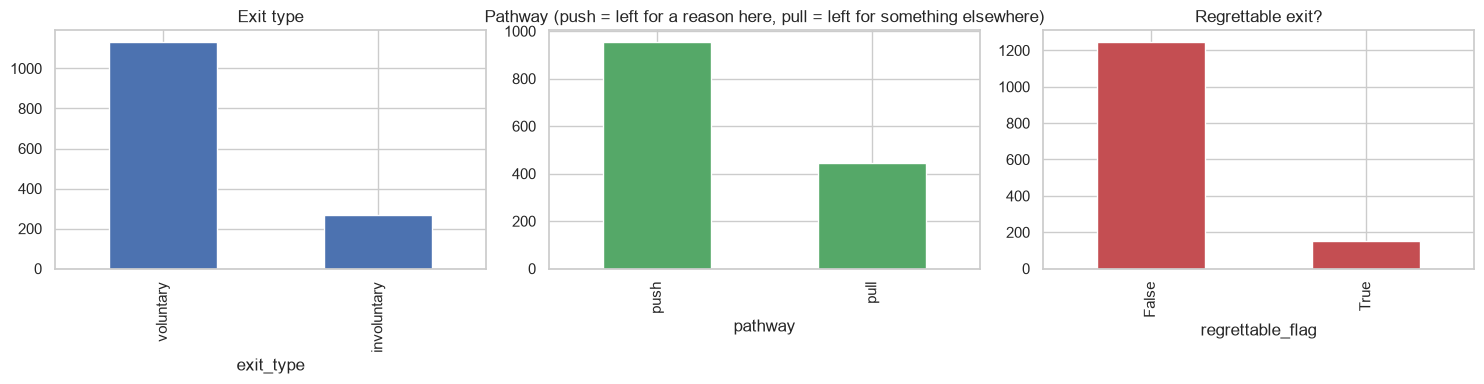

In [ ]:
# Voluntary vs involuntary and the push/pull framing from attrition_log
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
att["exit_type"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Exit type")
att["pathway"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Pathway (push = left for a reason here, pull = left for something elsewhere)")
att["regrettable_flag"].value_counts().plot(kind="bar", ax=axes[2], color="#C44E52")
axes[2].set_title("Regrettable exit?")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exit_type_pathway_regrettable.png", dpi=150)
plt.show()


## Engagement signals

The CEO letter specifically calls out survey non-responders as a population that "our data suggests is disproportionately at flight risk."

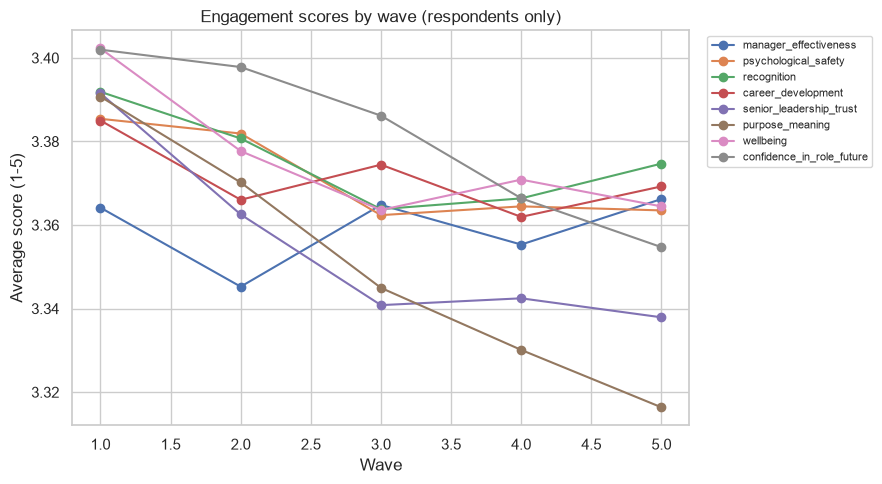

In [10]:
score_cols = ["manager_effectiveness", "psychological_safety", "recognition",
              "career_development", "senior_leadership_trust", "purpose_meaning",
              "wellbeing", "confidence_in_role_future"]

trend = eng[eng["response_flag"]].groupby("wave_number")[score_cols].mean()
fig, ax = plt.subplots(figsize=(9, 5))
trend.plot(ax=ax, marker="o")
ax.set_title("Engagement scores by wave (respondents only)")
ax.set_xlabel("Wave")
ax.set_ylabel("Average score (1-5)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/engagement_trend_by_wave.png", dpi=150)
plt.show()


low_responder
False     9.3
True     22.6
Name: status, dtype: float64


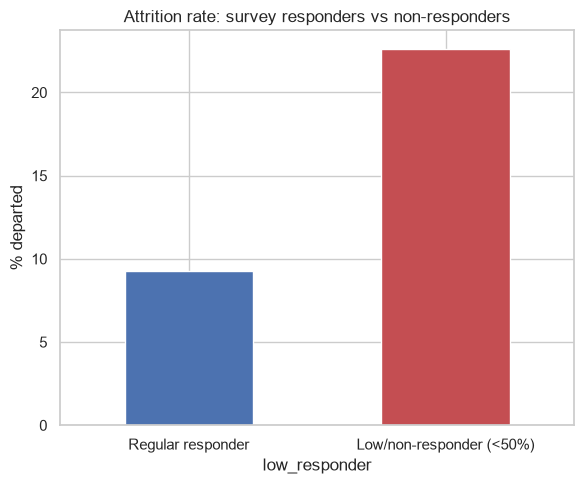

In [11]:
# Non-response as a flight-risk signal
resp_rate = eng.groupby("employee_id")["response_flag"].mean().rename("survey_response_rate")
emp_eng = emp.set_index("employee_id").join(resp_rate)
emp_eng["low_responder"] = emp_eng["survey_response_rate"] < 0.5

attrition_by_responder = emp_eng.groupby("low_responder")["status"].apply(lambda s: (s == "departed").mean() * 100)
print(attrition_by_responder.round(1))

fig, ax = plt.subplots(figsize=(6, 5))
attrition_by_responder.rename({False: "Regular responder", True: "Low/non-responder (<50%)"}).plot(
    kind="bar", ax=ax, color=["#4C72B0", "#C44E52"]
)
ax.set_title("Attrition rate: survey responders vs non-responders")
ax.set_ylabel("% departed")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/attrition_by_survey_response.png", dpi=150)
plt.show()


## Performance & compensation

Checks compensation compression for high-potential employees, noted from the annual report, and whether performance/promotion signals relate to attrition.

hipo_flag
False    0.952
True     0.879
Name: compa_ratio, dtype: float64


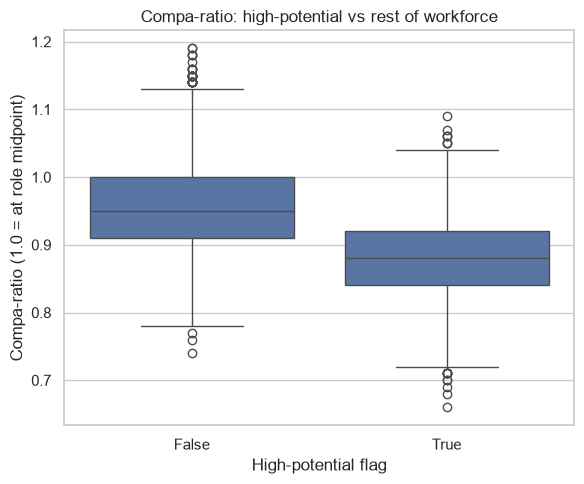

In [12]:
compa_by_hipo = emp.groupby("hipo_flag")["compa_ratio"].mean()
print(compa_by_hipo.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=emp, x="hipo_flag", y="compa_ratio", ax=ax)
ax.set_title("Compa-ratio: high-potential vs rest of workforce")
ax.set_xlabel("High-potential flag")
ax.set_ylabel("Compa-ratio (1.0 = at role midpoint)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/compa_ratio_by_hipo.png", dpi=150)
plt.show()


performance_rating
Unsatisfactory        10.1
Below Expectations    11.0
Meets Expectations    10.7
High Performer        10.5
Outstanding            9.4
Name: status, dtype: float64


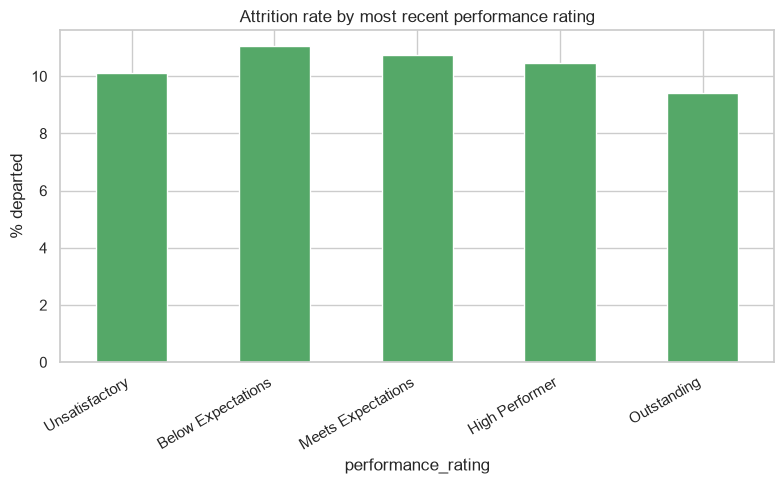

In [13]:
# Does a Below Expectations / Unsatisfactory rating precede departure, or are we losing strong performers?
latest_perf = perf.sort_values("review_date").groupby("employee_id").tail(1)
emp_perf = emp.set_index("employee_id").join(latest_perf.set_index("employee_id")["performance_rating"])

rate_by_rating = emp_perf.groupby("performance_rating")["status"].apply(lambda s: (s == "departed").mean() * 100)
rate_by_rating = rate_by_rating.reindex(["Unsatisfactory", "Below Expectations", "Meets Expectations", "High Performer", "Outstanding"])
print(rate_by_rating.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
rate_by_rating.plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Attrition rate by most recent performance rating")
ax.set_ylabel("% departed")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/attrition_by_performance_rating.png", dpi=150)
plt.show()


# Takeaways for initial mentor meeting

1. Entity_B cohort: ~15% attrition compared to ~10% in NovaCorp-Origin. Matches the annual report's "primary integration risk for FY2026."
2. Risk & Compliance Director level (role_level 4) spikes to ~22%, vs ~12% department-wide. Sharper than the report states, check sample size first.
3. Survey non-responders leave at ~2x the rate of respondents. A testable version of the CEO's "flight risk" claim.
4. High-potential employees show pay compression (lower compa-ratio) than the rest of the workforce. Matches the report's "7-8 point compression" claim.
5. Performance vs attrition needs a clean read: are we losing low performers (managed exits) or high performers (regrettable loss)? Ties to `regrettable_flag`.

Questions to ask:

Which of these causes is worth committing to for this project?
Many of these causes have been generally outlined in annual report by CEO (is this a trap?)
Do these small-sample points (e.g. R&C Director level) hold up statistically?
Is current solution (People Investment Programme, $47 mil) targeting the right areas, etc?